# Positive electrode degradation

This walks through to model the degradation of a high-nickel positive electrode with PyBaMM. The model is based on the shrinking-core model of Ghosh et al. (2021) that shows that at high states of charge the NMC811 particle surface transforms into a more stable rock-salt/spinel shell due to the release of oxygen that diffuses out through the shell. This shell grows inward and causes the positive core to shrink. Zhuo et al. (2023) developed a DFN/P2D model for this and used it to quantify loss of active material and loss of cyclable lithium and the resulting capacity fade.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pybamm

The degradation is enabled with the `"positive electrode degradation"` option. It is available for the SPM, where every positive particle is represented by one x-averaged particle, and for the DFN/P2D, where the phase boundary is analyzed through the thickness of the electrode. The `Zhuo2023` parameter set describes the NMC811/SiC 18650 cell used by Zhuo et al.

In [2]:
parameter_values = pybamm.ParameterValues("Zhuo2023")
model = pybamm.lithium_ion.SPM({"positive electrode degradation": "true"})

Following Zhuo et al cycling ageing tests, cycle the cell between 2.8 V and 4.2 V at 0.5 C, hold at each voltage limit and rest after each half cycle.

In [3]:
experiment = pybamm.Experiment(
    [
        (
            "Charge at 0.5 C until 4.2 V",
            "Hold at 4.2 V until C/50",
            "Rest for 60 minutes",
            "Discharge at 0.5 C until 2.8 V",
            "Hold at 2.8 V until C/50",
            "Rest for 60 minutes",
        )
    ]
    * 5,
    period="2 minutes",
)
sim = pybamm.Simulation(model, parameter_values=parameter_values, experiment=experiment)
solution = sim.solve(calc_esoh=False)

The phase boundary between the core and the shell, normalised by the particle radius, progresses inward during every charge as the core surface concentration decreases below the threshold for the phase transition. Hence, each cycle causes loss of active material from the positive electrode. Theere is also loss of lithium inventory due to the lithium trapped in the shell (degraded core).

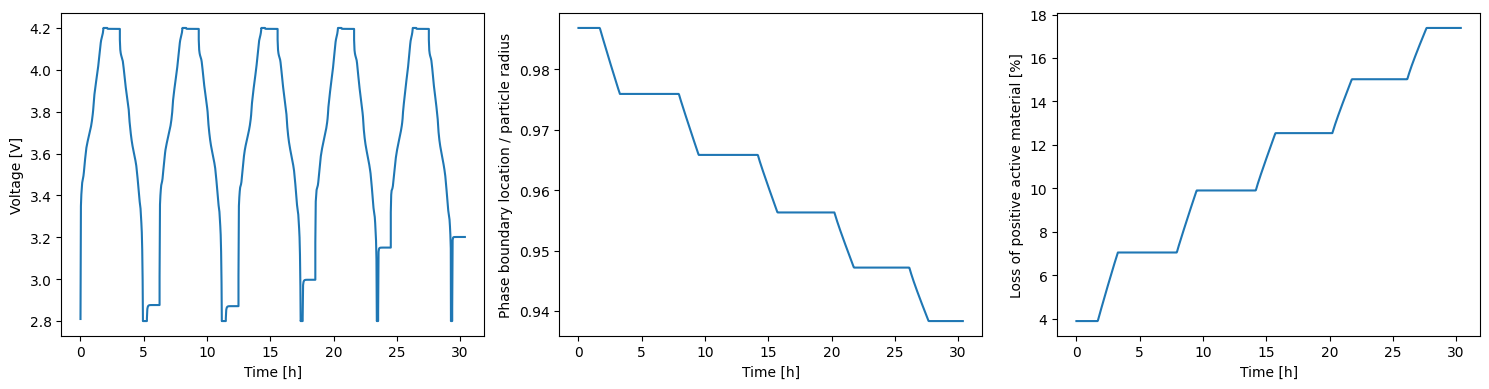

In [4]:
t = solution.t / 3600
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t, solution["Voltage [V]"](solution.t))
axes[0].set_ylabel("Voltage [V]")
axes[1].plot(t, solution["X-averaged moving phase boundary location"](solution.t))
axes[1].set_ylabel("Phase boundary location / particle radius")
axes[2].plot(
    t,
    100 * solution["X-averaged positive particle shell volume fraction"](solution.t),
)
axes[2].set_ylabel("Loss of positive active material [%]")
for ax in axes:
    ax.set_xlabel("Time [h]")
plt.tight_layout()

The discharge capacity decreases from cycle to cycle.

Text(0, 0.5, 'Discharge capacity [A.h]')

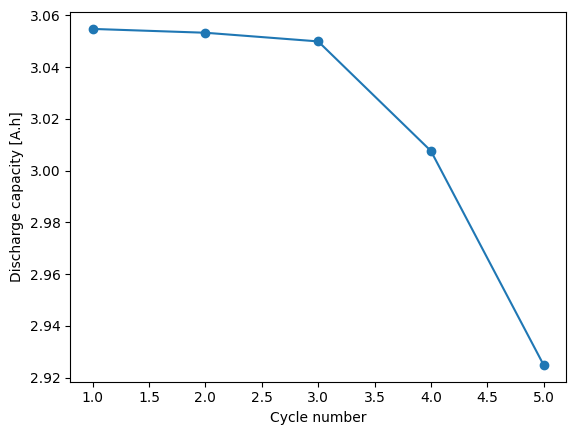

In [5]:
discharge_capacities = []
for cycle in solution.cycles:
    discharge = cycle.steps[3]
    capacity = discharge["Discharge capacity [A.h]"]
    discharge_capacities.append(
        float(capacity(discharge.t[-1]) - capacity(discharge.t[0]))
    )

plt.plot(np.arange(1, len(discharge_capacities) + 1), discharge_capacities, "o-")
plt.xlabel("Cycle number")
plt.ylabel("Discharge capacity [A.h]")

In the DFN/P2D the degradation actually varies throughout the electrode. Also, the oxygen released at the phase boundary flows into tthe shell. To simulate, charge a fresh cell at 1C and hold it at 4.2 V.

In [6]:
dfn = pybamm.lithium_ion.DFN({"positive electrode degradation": "true"})
experiment = pybamm.Experiment(
    ["Charge at 1 C until 4.2 V", "Hold at 4.2 V until C/100", "Rest for 30 minutes"]
)
sim_dfn = pybamm.Simulation(
    dfn, parameter_values=parameter_values, experiment=experiment
)
sim_dfn.solve(calc_esoh=False)
sim_dfn.plot(
    [
        "Voltage [V]",
        "Moving phase boundary location",
        "Positive shell concentration of oxygen [mol.m-3]",
    ],
    time_unit="minutes",
)

interactive(children=(FloatSlider(value=0.0, description='t', max=126.11395344201732, step=1.2611395344201732)…

## References

The relevant papers for this notebook are:

In [7]:
pybamm.print_citations()

[1] Joel A. E. Andersson, Joris Gillis, Greg Horn, James B. Rawlings, and Moritz Diehl. CasADi – A software framework for nonlinear optimization and optimal control. Mathematical Programming Computation, 11(1):1–36, 2019. doi:10.1007/s12532-018-0139-4.
[2] Von DAG Bruggeman. Berechnung verschiedener physikalischer konstanten von heterogenen substanzen. i. dielektrizitätskonstanten und leitfähigkeiten der mischkörper aus isotropen substanzen. Annalen der physik, 416(7):636–664, 1935.
[3] Marc Doyle, Thomas F. Fuller, and John Newman. Modeling of galvanostatic charge and discharge of the lithium/polymer/insertion cell. Journal of the Electrochemical society, 140(6):1526–1533, 1993. doi:10.1149/1.2221597.
[4] Abir Ghosh, Jamie M. Foster, Gregory Offer, and Monica Marinescu. A shrinking-core model for the degradation of high-nickel cathodes (nmc811) in li-ion batteries: passivation layer growth and oxygen evolution. Journal of The Electrochemical Society, 168(2):020509, 2021. doi:10.1149/1